In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay
)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

with open('../models/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train churn rate:", f"{y_train.mean():.1%}")
print("y_test  churn rate:", f"{y_test.mean():.1%}")
print("\nAll data loaded!")



X_train: (8260, 35)
X_test:  (1407, 35)
y_train churn rate: 50.0%
y_test  churn rate: 26.6%

All data loaded!


In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=== Logistic Regression ===")
print(f"ROC-AUC: {auc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['No churn', 'Churned']))

=== Logistic Regression ===
ROC-AUC: 0.8193

              precision    recall  f1-score   support

    No churn       0.86      0.83      0.84      1033
     Churned       0.57      0.62      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.77      0.78      1407



In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Random Forest ===")
print(f"ROC-AUC: {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['No churn', 'Churned']))


=== Random Forest ===
ROC-AUC: 0.8357

              precision    recall  f1-score   support

    No churn       0.88      0.80      0.84      1033
     Churned       0.56      0.68      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.77      0.78      1407



In [7]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("\n=== XGBoost ===")
print(f"ROC-AUC: {auc_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=['No churn', 'Churned']))

[0]	validation_0-logloss:0.67496
[50]	validation_0-logloss:0.45891
[100]	validation_0-logloss:0.44725
[150]	validation_0-logloss:0.45006
[200]	validation_0-logloss:0.45097
[250]	validation_0-logloss:0.45336
[299]	validation_0-logloss:0.45662

=== XGBoost ===
ROC-AUC: 0.8260

              precision    recall  f1-score   support

    No churn       0.85      0.84      0.85      1033
     Churned       0.57      0.60      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.77      0.78      1407



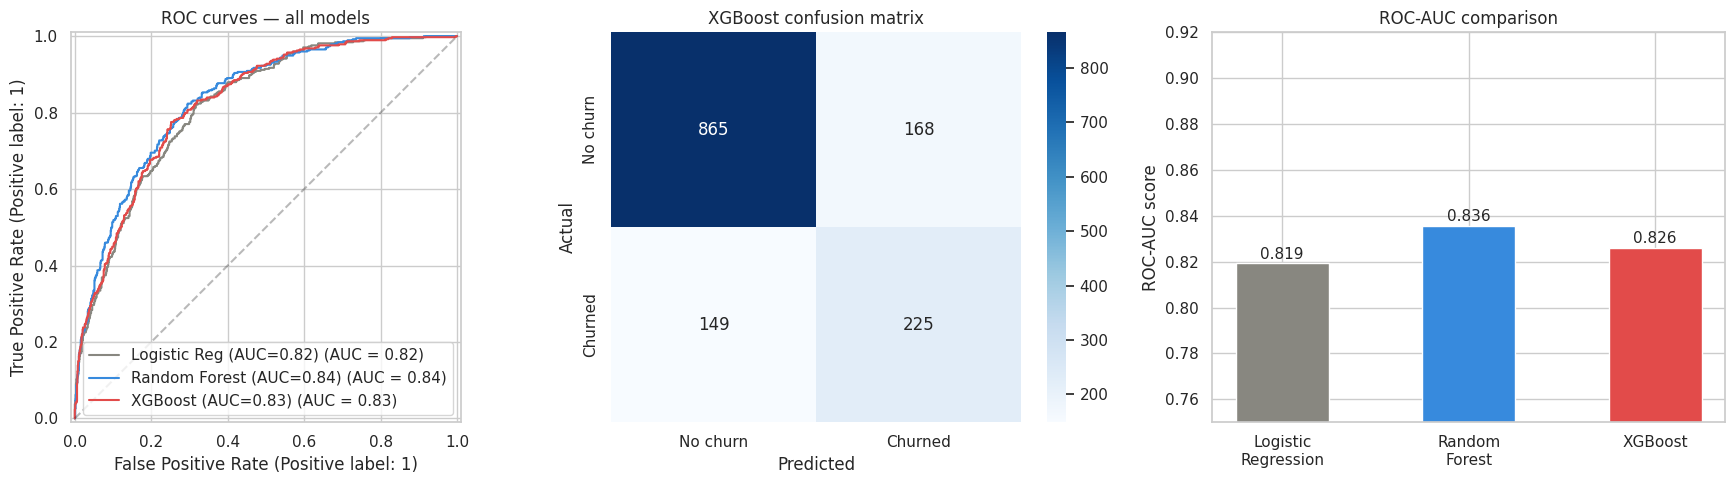


Model comparison saved to model_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr, name=f'Logistic Reg (AUC={auc_lr:.2f})',
    ax=axes[0], color='#888780')
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf, name=f'Random Forest (AUC={auc_rf:.2f})',
    ax=axes[0], color='#378ADD')
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb, name=f'XGBoost (AUC={auc_xgb:.2f})',
    ax=axes[0], color='#E24B4A')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_title('ROC curves — all models')

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No churn','Churned'],
            yticklabels=['No churn','Churned'],
            ax=axes[1])
axes[1].set_title('XGBoost confusion matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
aucs   = [auc_lr, auc_rf, auc_xgb]
colors = ['#888780', '#378ADD', '#E24B4A']
bars = axes[2].bar(models, aucs, color=colors, width=0.5)
axes[2].set_ylim(0.75, 0.92)
axes[2].set_title('ROC-AUC comparison')
axes[2].set_ylabel('ROC-AUC score')
for bar, auc in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{auc:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../model_comparison.png', dpi=150)
plt.show()

print("\nModel comparison saved to model_comparison.png")

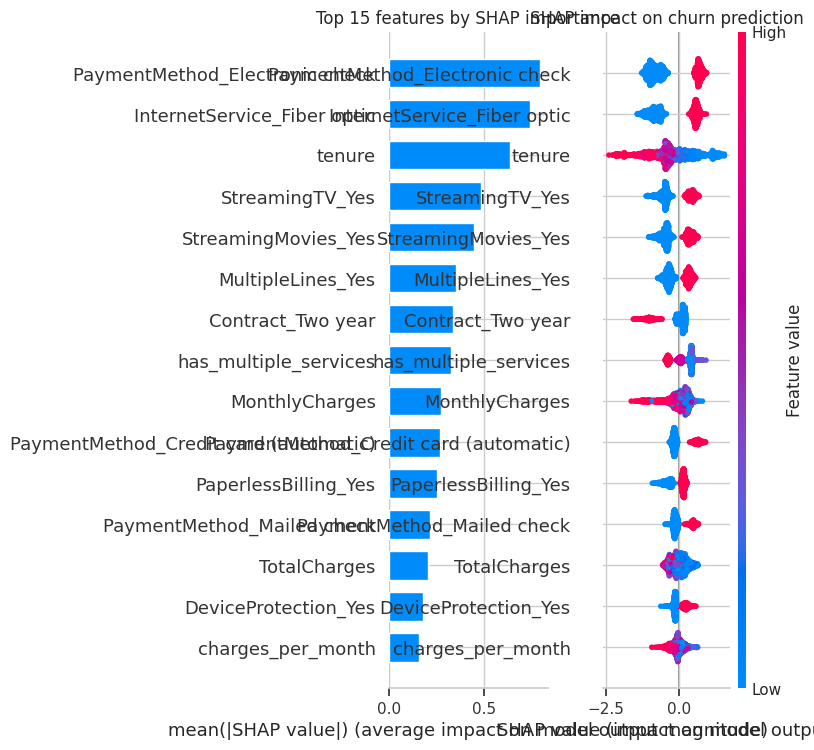


Top 5 churn drivers:
  1. PaymentMethod_Electronic check: 0.7973
  2. InternetService_Fiber optic: 0.7428
  3. tenure: 0.6369
  4. StreamingTV_Yes: 0.4836
  5. StreamingMovies_Yes: 0.4500


In [9]:
import shap

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test,
                  plot_type='bar',
                  max_display=15,
                  show=False)
axes[0].set_title('Top 15 features by SHAP importance')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
axes[1].set_title('SHAP impact on churn prediction')

plt.tight_layout()
plt.savefig('../shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop 5 churn drivers:")
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)
for i, (feat, val) in enumerate(mean_shap.head(5).items()):
    print(f"  {i+1}. {feat}: {val:.4f}")

In [10]:
with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("Model saved to models/xgb_model.pkl")

print("\n=== Final model summary ===")
print(f"Model:        XGBoost")
print(f"ROC-AUC:      {auc_xgb:.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1 Score:     {f1:.4f}")
print(f"True positives (caught churners): {tp}")
print(f"False negatives (missed churners): {fn}")
print(f"\nBaseline (logistic) AUC: {auc_lr:.4f}")
print(f"XGBoost improvement:     +{auc_xgb - auc_lr:.4f}")

Model saved to models/xgb_model.pkl

=== Final model summary ===
Model:        XGBoost
ROC-AUC:      0.8260
Precision:    0.5725
Recall:       0.6016
F1 Score:     0.5867
True positives (caught churners): 225
False negatives (missed churners): 149

Baseline (logistic) AUC: 0.8193
XGBoost improvement:     +0.0067
